In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Дифференцирование

In [ ]:
def grad(outputs, inputs):
    """Computes the partial derivative of 
    an output with respect to an input.
    Args:
        outputs: (N, 1) tensor - surfaces
        inputs: (N, D) tensor - ts
    """
    return torch.autograd.grad(
        outputs, inputs, grad_outputs=torch.ones_like(outputs), create_graph=True
    )

Уже продифференцируемое уравнение, для сравнения и генерации данных:

In [ ]:
def grinding_kinetics(time, Smax, S0, k):
    S = Smax + (S0 - Smax) * np.exp(-k * time)
    return S

Text(0.5, 0, 'Время, с')

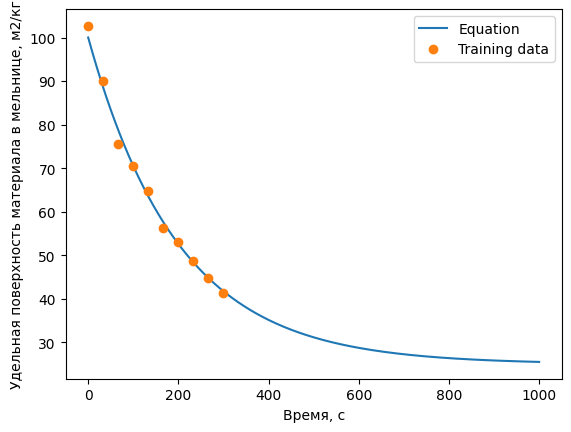

In [ ]:
np.random.seed(10)
# Ниже параметры неверные, но взяты для примера
Smax = 25
S0 = 100
k = 0.005
times = np.linspace(0, 1000, 1000) # 1000 чисел от 0 до 1000
# eq = grinding_kinetics(time=times,Smax=Smax, S0=S0, k=k)
# surfaces = eq(times)
surfaces = grinding_kinetics(time=times,Smax=Smax, S0=S0, k=k)

# Make training data
t = np.linspace(0, 300, 10) # 10 чисел времени от 0 до 300 
S = grinding_kinetics(time=t,Smax=Smax, S0=S0, k=k) +  2 * np.random.randn(10)

plt.plot(times, surfaces)
plt.plot(t, S, 'o')
plt.legend(['Equation', 'Training data'])
plt.ylabel('Удельная поверхность материала в мельнице, м2/кг')
plt.xlabel('Время, с')

# Архитектура модели

input_dim — размерность входных данных;<br>
output_dim — размерность выходных данных;<br>
n_units — число нейронов в скрытых слоях (по умолчанию 100);<br>
epochs — количество эпох обучения (1000);<br>
loss — основная функция потерь (MSE по умолчанию);<br>
lr — скорость обучения (0.001);<br>
loss2 — дополнительная функция потерь (физическая);<br>
loss2_weight — вес второй потери (0.5).<br>
k - доп.дифференцируемый параметр

Структура:

4 скрытых слоя по 100 нейронов;
После каждого линейного слоя — ReLU (функция активации);
Выходной слой — линейный (без активации).

In [9]:
import torch.nn as nn
import torch.optim as optim
# import torch.utils.data as thdat

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Конвертация массив NumPy в тензор PyTorch
def np_to_th(x):
    n_samples = len(x)
    return torch.from_numpy(x).to(torch.float).to(DEVICE).reshape(n_samples, -1)


class Pinn(nn.Module):
    def __init__(
        self,
        input_dim,
        output_dim,
        n_units=100,
        epochs=1000,
        loss=nn.MSELoss(),
        lr=1e-3,
        loss2=None,
        loss2_weight=0.5,
    ) -> None:
        super().__init__()

        self.epochs = epochs
        self.loss = loss
        self.loss2 = loss2
        self.loss2_weight = loss2_weight
        self.lr = lr
        self.n_units = n_units
        self.k = nn.Parameter(data=torch.tensor([0.])) # Начальное значение 0, обучаемый параметр 

        self.layers = nn.Sequential(
            nn.Linear(input_dim, self.n_units),
            nn.ReLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.ReLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.ReLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.ReLU(),
        )
        self.out = nn.Linear(self.n_units, output_dim)

    def forward(self, x):
        h = self.layers(x)
        out = self.out(h)

        return out

    def fit(self, X, y):
        Xt = np_to_th(X)
        yt = np_to_th(y)

        optimiser = optim.Adam(self.parameters(), lr=self.lr)
        self.train()
        losses = []
        for ep in range(self.epochs):
            optimiser.zero_grad()
            outputs = self.forward(Xt)
            loss = self.loss(yt, outputs)
            if self.loss2:
                loss += self.loss2_weight * self.loss2(self)
            loss.backward()
            optimiser.step()
            losses.append(loss.item())
            if ep % int(self.epochs / 10) == 0:
                print(f"Epoch {ep}/{self.epochs}, loss: {losses[-1]:.2f}")
        return losses

    def predict(self, X):
        self.eval()
        out = self.forward(np_to_th(X))
        return out.detach().cpu().numpy()


LOSS

In [ ]:
def physics_loss(model: torch.nn.Module):
    ts = torch.linspace(0, 1000, steps=1000,).view(-1,1).requires_grad_(True).to(DEVICE)
    surfaces = model(ts)
    dS = grad(surfaces, ts)[0]
    pde = model.k * (Smax - surfaces) - dS
    
    return torch.mean(pde**2)



добавить автодиф по z

Epoch 0/40000, loss: 4816.59
Epoch 4000/40000, loss: 2522.54
Epoch 8000/40000, loss: 2203.93
Epoch 12000/40000, loss: 456.90
Epoch 16000/40000, loss: 6.31
Epoch 20000/40000, loss: 1.38
Epoch 24000/40000, loss: 0.82
Epoch 28000/40000, loss: 0.54
Epoch 32000/40000, loss: 0.38
Epoch 36000/40000, loss: 0.34


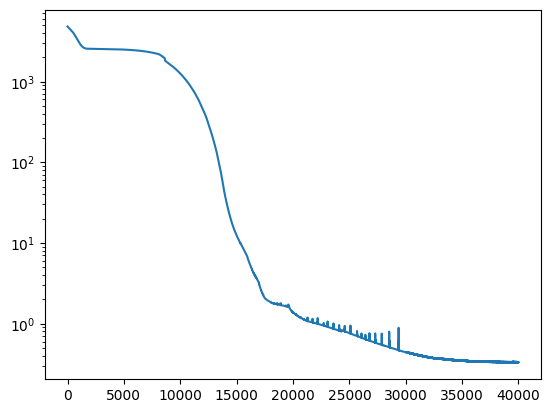

In [11]:
pinn = Pinn(1, 1, loss2=physics_loss, loss2_weight=1, epochs=40000, lr= 5e-6).to(DEVICE)

losses = pinn.fit(t, S)
plt.plot(losses)
plt.yscale('log')

Parameter containing:
tensor([0.0051], requires_grad=True)


Text(0.5, 0, 'Время, с')

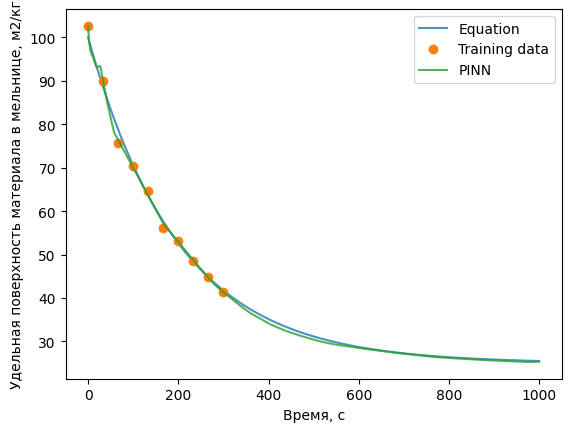

In [12]:
preds = pinn.predict(times)
print(pinn.k)

plt.plot(times, surfaces, alpha=0.8)
plt.plot(t, S, 'o')
plt.plot(times, preds, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'PINN'])
plt.ylabel('Удельная поверхность материала в мельнице, м2/кг')
plt.xlabel('Время, с')

## Версия с dt и dz

In [ ]:
# нужно переписать
def grinding_kinetics(time, Smax, S0, k):
    S = Smax + (S0 - Smax) * np.exp(-k * time)
    return S

In [ ]:
np.random.seed(15)
# Ниже параметры неверные, но взяты для примера
Smax = 500 #m2/кг
S0 = 100
k = 0.005
times = np.linspace(0, 1800, 1000) # 1000 чисел от 0 до 1800 (секунды, т.е. 30 минут)
# eq = grinding_kinetics(time=times,Smax=Smax, S0=S0, k=k)
# surfaces = eq(times)
surfaces = grinding_kinetics(time=times,Smax=Smax, S0=S0, k=k)

# Make training data
t_train = np.linspace(0, 300, 10) # 10 чисел времени от 0 до 300 
S_train = grinding_kinetics(time=t,Smax=Smax, S0=S0, k=k) +  2 * np.random.randn(10)

plt.plot(times, surfaces)
plt.plot(t, S, 'o')
plt.legend(['Equation', 'Training data'])
plt.ylabel('Удельная поверхность материала в мельнице, м2/кг')
plt.xlabel('Время, с')

In [ ]:
import torch.nn as nn
import torch.optim as optim
# import torch.utils.data as thdat

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Конвертация массив NumPy в тензор PyTorch
def np_to_th(x):
    n_samples = len(x)
    return torch.from_numpy(x).to(torch.float).to(DEVICE).reshape(n_samples, -1)


class Pinn(nn.Module):
    def __init__(
        self,
        input_dim,
        output_dim,
        n_units=100,
        epochs=1000,
        loss=nn.MSELoss(),
        lr=1e-3,
        loss2=None,
        loss2_weight=0.5,
    ) -> None:
        super().__init__()

        self.epochs = epochs
        self.loss = loss
        self.loss2 = loss2
        self.loss2_weight = loss2_weight
        self.lr = lr
        self.n_units = n_units
        self.k = nn.Parameter(data=torch.tensor([0.])) # Начальное значение 0, обучаемый параметр 
        self.

        self.layers = nn.Sequential(
            nn.Linear(input_dim, self.n_units),
            nn.ReLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.ReLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.ReLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.ReLU(),
        )
        self.out = nn.Linear(self.n_units, output_dim)

    def forward(self, x):
        h = self.layers(x)
        out = self.out(h)

        return out

    def fit(self, X, y):
        Xt = np_to_th(X)
        yt = np_to_th(y)

        optimiser = optim.Adam(self.parameters(), lr=self.lr)
        self.train()
        losses = []
        for ep in range(self.epochs):
            optimiser.zero_grad()
            outputs = self.forward(Xt)
            loss = self.loss(yt, outputs)
            if self.loss2:
                loss += self.loss2_weight * self.loss2(self)
            loss.backward()
            optimiser.step()
            losses.append(loss.item())
            if ep % int(self.epochs / 10) == 0:
                print(f"Epoch {ep}/{self.epochs}, loss: {losses[-1]:.2f}")
        return losses

    def predict(self, X):
        self.eval()
        out = self.forward(np_to_th(X))
        return out.detach().cpu().numpy()


In [ ]:
def physics_loss(model: torch.nn.Module):
    ts = torch.linspace(0, 1000, steps=1000,).view(-1,1).requires_grad_(True).to(DEVICE)
    surfaces = model(ts)
    dS = grad(surfaces, ts)[0]
    pde = model.k * (Smax - surfaces) - dS
    
    return torch.mean(pde**2)

In [ ]:
preds = pinn.predict(times)
print(pinn.k)

plt.plot(times, surfaces, alpha=0.8)
plt.plot(t, S, 'o')
plt.plot(times, preds, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'PINN'])
plt.ylabel('Удельная поверхность материала в мельнице, м2/кг')
plt.xlabel('Время, с')